# IND320 – Compulsory work 1: Norwegian water reservoirs

## Links
- **GitHub repository:** https://github.com/maryanahmed11011-pixel/IND320.prosjekt.maryan
- **Streamlit app:** https://ind320prosjektmaryan-lmvbjxajmrnrqkykq8ivne.streamlit.app/
- **Screencast:**https://nmbu.cloud.panopto.eu/Panopto/Pages/Viewer.aspx?id=4eb306de-980d-49b1-8115-b4d4008c116b 


## KI bruk 
KI-verktøy ble brukt gjennom hele arbeidet. Jeg brukte Claude (Anthropic) som en steg-for-steg-assistent for å sette opp Python-miljøet i VS Code, konfigurere Git og GitHub og feilsøke problemer i terminalen. Claude foreslo også kode for innlesing og navnendring av dataene, for plottene i notebooken og for Streamlit-sidene. I tillegg til å hjelpe til med å rette et layoutproblem i det interaktive plottet, og  til å skrive utkast til arbeidsloggen basert på min egen arbeidsprosess. Gemini ble brukt til å lage et første utkast til oppgaveplan. Jeg har selv kjørt, testet og kontrollert all koden, både lokalt og i den publiserte appen, og jeg er ansvarlig for det endelige innholdet.


## Arbeidslogg 
Målet med denne obligatoriske oppgaven var å legge grunnlaget for IND320-prosjektet: en Jupyter Notebook for å utforske dataene og en Streamlit-app publisert fra et offentlig GitHub-repo.
Å sette opp utviklingsmiljøet tok lengre tid enn forventet. PC-en min hadde flere Python-installasjoner, og den første pakkeinstallasjonen havnet i feil installasjon. Jeg løste dette ved å lage et virtuelt miljø (.venv) i prosjektmappen og installere streamlit, pandas, matplotlib og jupyter der. Jeg lærte å sjekke at terminalen viser (.venv) før jeg kjører kommandoer, og å bruke python -m pip slik at pakkene havner i det aktive miljøet. En .gitignore-fil hindrer at miljøet og cache-filer lastes opp til repoet.
Deretter initialiserte jeg Git, koblet mappen til GitHub og satte opp navn og e-post. Et manglende anførselstegn gjorde at feil e-postadresse ble lagret, noe jeg rettet med --replace-all. Dette lærte meg å lese meldingene i terminalen nøye.
Datafilen, reservoirs.csv, ligger i D2Dbook/data i kursets repo. Da jeg undersøkte den, så jeg at dataene er i langt format: hver rad er én uke for ett område fra 1995 til 2026, og filen inneholder hele Norge (NO), de fem prisområdene (EL) og vassdragsregioner (VASS). For å få én tydelig tidsserie brukte jeg totalen for hele Norge og sorterte radene etter dato. Jeg oversatte alle kolonnenavnene til engelsk, for eksempel fyllingsgrad til filling_degree, og gjorde datoene om til datetime.
I notebooken plottet jeg hver tallkolonne for seg og deretter alle sammen. Siden kolonnene har svært ulik skala (rundt 87 TWh mot andeler mellom 0 og 1), brukte jeg min-max-normalisering for å få dem på en felles skala fra 0 til 1. De tre tekst- og datokolonnene kan ikke plottes som tidsserier.
Streamlit-appen har fire sider, og app.py lager sidemenyen med st.navigation. En felles utils.py leser dataene med @st.cache_data, slik at filen bare lastes én gang selv om Streamlit kjører skriptet på nytt ved hver interaksjon. Forsiden viser nøkkeltall for siste uke og sammenligner årets nivå med tidligere år. Tabellsiden har én rad per tallkolonne med en LineChartColumn for første måned. Siden dataene er ukentlige, inneholder denne måneden fire verdier. Plottsiden bruker st.selectbox og st.select_slider med første måned som standard. Etter publiseringen endret plottet størrelse når slideren ble flyttet, fordi Streamlit beskar bildet automatisk. Jeg løste dette med fast layout og faste akser, og ved å vise figuren med st.image.
Alt i alt har jeg lært hvordan utviklingsmiljøer og Git fungerer i praksis, og hvordan lokal analyse i en notebook kan gjøres om til en interaktiv app på nett.


## 1. Import libraries

In [17]:
# pandas brukes til å lese og behandle tabelldata, matplotlib til plotting
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display  # viser tabeller pent i notebooken

## 2. Read the data and rename headers to English

In [18]:
# Les CSV-filen (ligger i data-mappen i prosjektet)
df_raw = pd.read_csv("data/reservoirs.csv")

# Oversett kolonnenavnene fra norsk til engelske, forklarende navn
rename_map = {
    "dato_Id": "date",
    "omrType": "area_type",
    "omrnr": "area_number",
    "iso_aar": "iso_year",
    "iso_uke": "iso_week",
    "fyllingsgrad": "filling_degree",
    "kapasitet_TWh": "capacity_TWh",
    "fylling_TWh": "filling_TWh",
    "neste_Publiseringsdato": "next_publication_date",
    "fyllingsgrad_forrige_uke": "filling_degree_prev_week",
    "endring_fyllingsgrad": "filling_degree_change",
}
df = df_raw.rename(columns=rename_map)

# Gjør datokolonnen om til ekte datoer, så plottene får riktig tidsakse
df["date"] = pd.to_datetime(df["date"])
df.columns.tolist()

['date',
 'area_type',
 'area_number',
 'iso_year',
 'iso_week',
 'filling_degree',
 'capacity_TWh',
 'filling_TWh',
 'next_publication_date',
 'filling_degree_prev_week',
 'filling_degree_change']

## 3. Inspect the contents

In [19]:
# Størrelse på datasettet (rader, kolonner) og datatyper
print("Shape:", df.shape)
df.info()

Shape: (14877, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14877 entries, 0 to 14876
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   date                      14877 non-null  datetime64[ns]
 1   area_type                 14877 non-null  object        
 2   area_number               14877 non-null  int64         
 3   iso_year                  14877 non-null  int64         
 4   iso_week                  14877 non-null  int64         
 5   filling_degree            14877 non-null  float64       
 6   capacity_TWh              14877 non-null  float64       
 7   filling_TWh               14877 non-null  float64       
 8   next_publication_date     14877 non-null  object        
 9   filling_degree_prev_week  14877 non-null  float64       
 10  filling_degree_change     14877 non-null  float64       
dtypes: datetime64[ns](1), float64(5), int64(3), object(2)
memory 

In [20]:
# Filen inneholder flere typer områder:
#   NO   = hele Norge (area_number 0)
#   EL   = strømområdene NO1-NO5 (area_number 1-5)
#   VASS = vassdragsregioner
print(df["area_type"].value_counts())
print("Date range:", df["date"].min().date(), "to", df["date"].max().date())

area_type
EL      8265
VASS    4959
NO      1653
Name: count, dtype: int64
Date range: 1995-01-08 to 2026-09-06


In [21]:
# Vi bruker totalen for hele Norge, slik at vi får én ukentlig tidsserie.
# Radene i filen står ikke i datorekkefølge, så vi sorterer etter dato.
norway = df[df["area_type"] == "NO"].sort_values("date").reset_index(drop=True)

# Alle tallkolonner plottes. Tekst- og datokolonner (date, area_type,
# next_publication_date) kan ikke plottes som tidsserier.
measure_cols = norway.select_dtypes("number").columns.tolist()


# Vis de første radene og et statistisk sammendrag
display(norway.head(10))
display(norway[measure_cols].describe().round(3))

,date,area_type,area_number,iso_year,iso_week,filling_degree,capacity_TWh,filling_TWh,next_publication_date,filling_degree_prev_week,filling_degree_change
0,1995-01-08,NO,0,1995,1,0.608274,87.43758,53.185986,0001-01-01T00:00:00,0.752703,-0.144430
1,1995-01-15,NO,0,1995,2,0.582372,87.43758,50.921207,0001-01-01T00:00:00,0.608274,-0.025902
2,1995-01-22,NO,0,1995,3,0.562412,87.43758,49.175980,0001-01-01T00:00:00,0.582390,-0.019977
3,1995-01-29,NO,0,1995,4,0.534508,87.43758,46.736122,0001-01-01T00:00:00,0.562412,-0.027904
4,1995-02-05,NO,0,1995,5,0.506486,87.43758,44.285900,0001-01-01T00:00:00,0.534489,-0.028003
5,1995-02-12,NO,0,1995,6,0.482046,87.43758,42.148940,0001-01-01T00:00:00,0.506489,-0.024443
6,1995-02-19,NO,0,1995,7,0.455887,87.43758,39.861680,0001-01-01T00:00:00,0.482039,-0.026152
7,1995-02-26,NO,0,1995,8,0.428471,87.43758,37.464466,0001-01-01T00:00:00,0.455887,-0.027416
8,1995-03-05,NO,0,1995,9,0.401259,87.43758,35.085133,0001-01-01T00:00:00,0.428471,-0.027212
9,1995-03-12,NO,0,1995,10,0.373207,87.43758,32.632317,0001-01-01T00:00:00,0.401259,-0.028052


,area_number,iso_year,iso_week,filling_degree,capacity_TWh,filling_TWh,filling_degree_prev_week,filling_degree_change
count,1653.0,1653.000,1653.000,1653.000,1653.000,1653.000,1653.000,1653.000
mean,0.0,2010.346,26.406,0.622,87.438,54.394,0.622,-0.000
std,0.0,9.149,15.022,0.196,0.000,17.135,0.196,0.028
min,0.0,1995.000,1.000,0.180,87.438,15.761,0.180,-0.144
25%,0.0,2002.000,13.000,0.461,87.438,40.274,0.461,-0.022
50%,0.0,2010.000,26.000,0.646,87.438,56.476,0.647,-0.006
75%,0.0,2018.000,39.000,0.789,87.438,69.012,0.789,0.016
max,0.0,2026.000,53.000,0.967,87.438,84.545,0.967,0.125


## 4. Plot each column separately

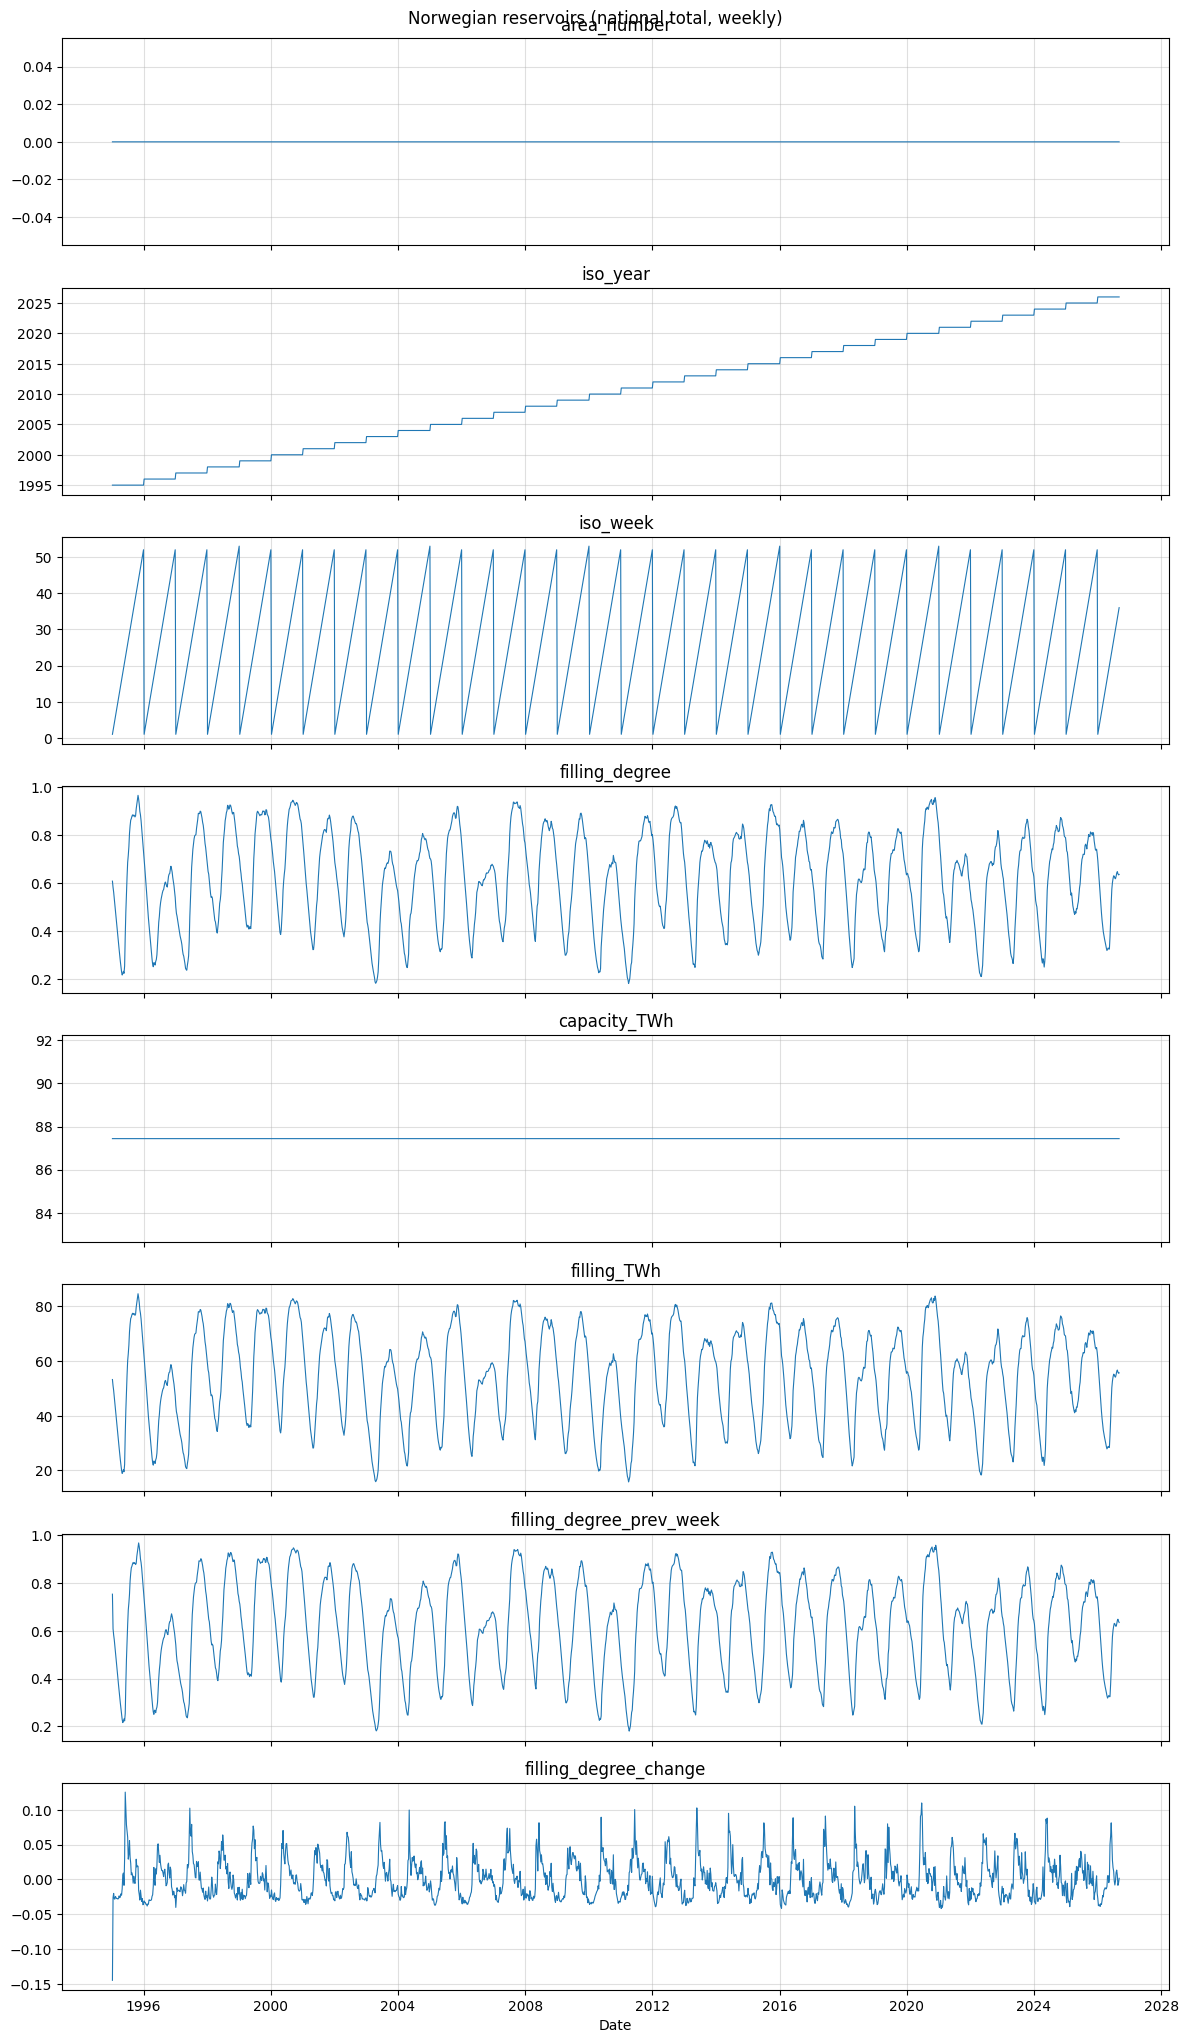

In [22]:
# Ett delplott per måleverdi, med felles tidsakse
fig, axes = plt.subplots(len(measure_cols), 1, figsize=(12, 2.6 * len(measure_cols)), sharex=True)

for ax, col in zip(axes, measure_cols):
    ax.plot(norway["date"], norway[col], linewidth=0.8)
    ax.set_title(col)
    ax.grid(True, alpha=0.4)

axes[-1].set_xlabel("Date")
fig.suptitle("Norwegian reservoirs (national total, weekly)")
plt.tight_layout()
plt.show()

## 5. Plot all columns together
Kolonnene har ulike skalaer: kapasitet og fylling måles i TWh (titalls TWh),
mens fyllingsgrad er en andel mellom 0 og 1, og endringen er et lite tall rundt 0.
For å kunne sammenligne formen på kurvene i ett plott, min-max-normaliseres
hver kolonne til skalaen 0–1.

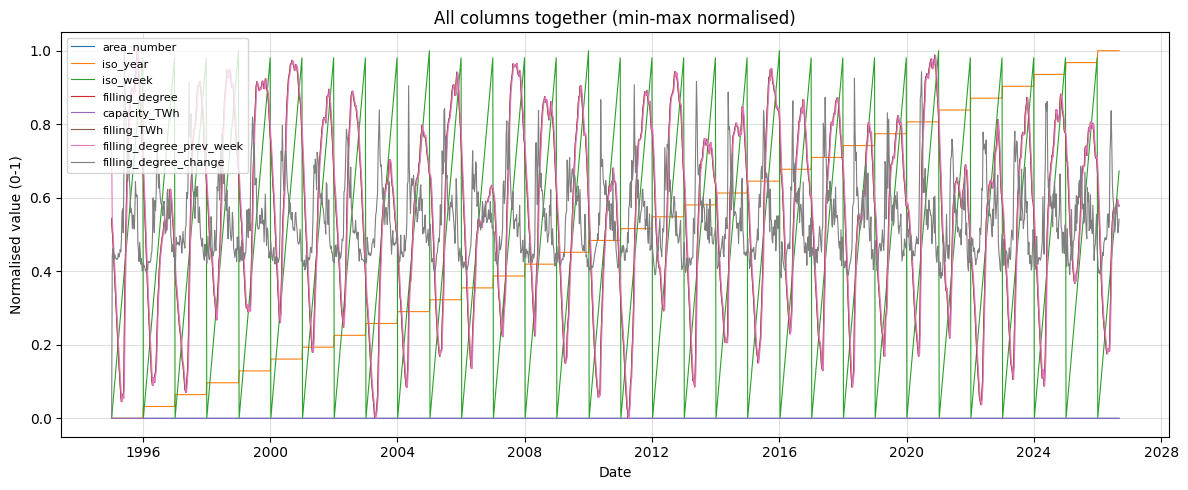

In [23]:
# Min-max-normalisering: (verdi - min) / (max - min) gir 0-1 for hver kolonne
values = norway[measure_cols]
spread = (values.max() - values.min()).replace(0, 1)  # unngå deling på 0 hvis en kolonne er konstant
normalised = (values - values.min()) / spread

fig, ax = plt.subplots(figsize=(12, 5))
for col in measure_cols:
    ax.plot(norway["date"], normalised[col], linewidth=0.8, label=col)

ax.set_title("All columns together (min-max normalised)")
ax.set_xlabel("Date")
ax.set_ylabel("Normalised value (0-1)")
ax.legend(loc="upper left", fontsize=8)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

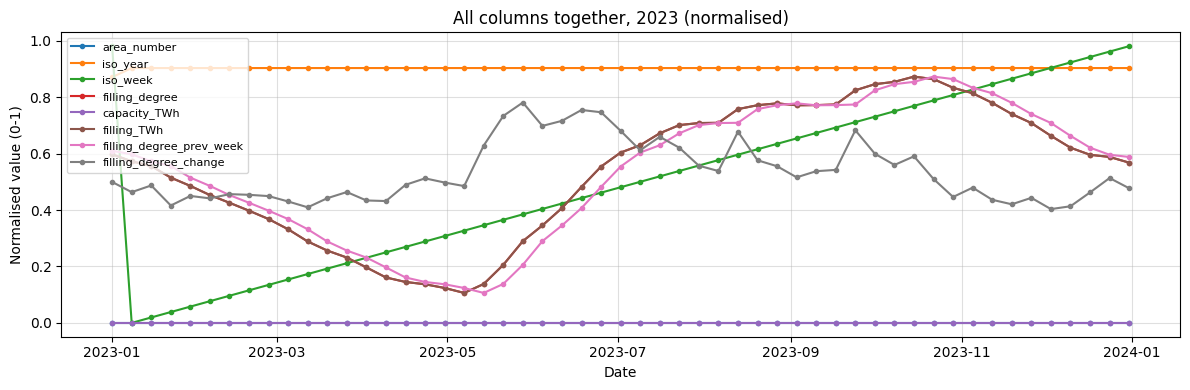

In [24]:
# Samme data for bare ett år, der sesongvariasjonen er lettere å se
one_year = norway[norway["date"].dt.year == 2023]
norm_year = (one_year[measure_cols] - values.min()) / spread

fig, ax = plt.subplots(figsize=(12, 4))
for col in measure_cols:
    ax.plot(one_year["date"], norm_year[col], marker="o", markersize=3, label=col)
ax.set_title("All columns together, 2023 (normalised)")
ax.set_xlabel("Date")
ax.set_ylabel("Normalised value (0-1)")
ax.legend(loc="upper left", fontsize=8)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()